# Stage 02 — German Credit Feature Analysis

This stage reviews feature semantics, data quality, target associations, redundancy and XAI readiness. It does not preprocess data or create a train/test split.


## 1. Setup and Stage 01 inputs

The local raw snapshot is used. Dataset 1 paths are not read or written by this notebook.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import chi2_contingency, spearmanr

RANDOM_STATE = 42
RAW_TARGET = "class"
ANALYSIS_TARGET = "TARGET"
EXPECTED_RAW_SHA256 = "f985b42636c9e28ce4fb3913738d1ebfd0f7947fda8d4406fe2ded5d84295acb"

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "german_credit":
    candidate = NOTEBOOK_DIR / "backend" / "ml" / "german_credit"
    if candidate.exists():
        NOTEBOOK_DIR = candidate
    else:
        raise RuntimeError("Run from backend/ml/german_credit or the project root.")
BACKEND_DIR = NOTEBOOK_DIR.parents[1]
RAW_PATH = BACKEND_DIR / "data" / "german_credit" / "raw" / "german_credit_raw.csv"
VARIABLES_PATH = BACKEND_DIR / "data" / "german_credit" / "raw" / "german_credit_variables.csv"
SUMMARY_PATH = BACKEND_DIR / "artifacts" / "german_credit" / "dataset_summary.json"
PROVENANCE_PATH = BACKEND_DIR / "artifacts" / "german_credit" / "dataset_provenance.json"
ARTIFACTS_DIR = BACKEND_DIR / "artifacts" / "german_credit"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
REQUIREMENTS_PATH = BACKEND_DIR / "requirements.txt"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
import hashlib

raw_bytes = RAW_PATH.read_bytes()
raw_sha256 = hashlib.sha256(raw_bytes).hexdigest()
raw_df = pd.read_csv(RAW_PATH)
variables = pd.read_csv(VARIABLES_PATH)
with SUMMARY_PATH.open(encoding="utf-8") as file:
    stage01_summary = json.load(file)
with PROVENANCE_PATH.open(encoding="utf-8") as file:
    provenance = json.load(file)

raw_features = [f"Attribute{number}" for number in range(1, 21)]
assert raw_sha256 == EXPECTED_RAW_SHA256
assert raw_df.shape == (1000, 21)
assert raw_features == raw_df.columns[:-1].tolist()
assert RAW_TARGET == raw_df.columns[-1]
assert raw_df[RAW_TARGET].value_counts().to_dict() == {1: 700, 2: 300}

print(f"Raw snapshot SHA-256 verified: {raw_sha256}")
print(f"Raw rows: {len(raw_df)}")
print(f"Raw predictors: {len(raw_features)}")
print(f"Target: {RAW_TARGET}")


Raw snapshot SHA-256 verified: f985b42636c9e28ce4fb3913738d1ebfd0f7947fda8d4406fe2ded5d84295acb
Raw rows: 1000
Raw predictors: 20
Target: class


## 2. Analysis target

The original `class` column is retained. An in-memory target maps good credit to 0 and bad/higher-risk credit to 1.


In [3]:
analysis_df = raw_df.copy()
analysis_df[ANALYSIS_TARGET] = analysis_df[RAW_TARGET].map({1: 0, 2: 1})
target_check = pd.DataFrame({
    "original_class": [1, 2],
    "analysis_TARGET": [0, 1],
    "meaning": ["Good credit risk", "Bad / higher-risk credit"],
    "count": [700, 300],
})
display(target_check)
assert analysis_df[ANALYSIS_TARGET].value_counts().to_dict() == {0: 700, 1: 300}


,original_class,analysis_TARGET,meaning,count
0,1,0,Good credit risk,700
1,2,1,Bad / higher-risk credit,300


## 3. Verified display and category mappings

Names and category labels follow the official UCI variable descriptions and codebook. Raw A-codes remain unchanged in the snapshot.


In [4]:
FEATURE_DISPLAY_MAPPING = {
    "Attribute1": "Checking account status",
    "Attribute2": "Credit duration (months)",
    "Attribute3": "Credit history",
    "Attribute4": "Credit purpose",
    "Attribute5": "Credit amount (DM)",
    "Attribute6": "Savings account status",
    "Attribute7": "Employment duration",
    "Attribute8": "Installment rate (% disposable income)",
    "Attribute9": "Personal status and sex",
    "Attribute10": "Other debtors or guarantors",
    "Attribute11": "Residence duration",
    "Attribute12": "Property",
    "Attribute13": "Age (years)",
    "Attribute14": "Other installment plans",
    "Attribute15": "Housing",
    "Attribute16": "Existing credits at bank",
    "Attribute17": "Job",
    "Attribute18": "Dependants",
    "Attribute19": "Registered telephone",
    "Attribute20": "Foreign worker",
}
CATEGORY_VALUE_MAPPING = {
    "Attribute1": {"A11": "< 0 DM", "A12": "0 to < 200 DM", "A13": ">= 200 DM or salary assignment >= 1 year", "A14": "No checking account"},
    "Attribute3": {"A30": "No credits taken or all credits paid duly", "A31": "All credits at this bank paid duly", "A32": "Existing credits paid duly to date", "A33": "Past payment delay", "A34": "Critical account or other existing credits"},
    "Attribute4": {"A40": "New car", "A41": "Used car", "A42": "Furniture or equipment", "A43": "Radio or television", "A44": "Domestic appliances", "A45": "Repairs", "A46": "Education", "A47": "Vacation (UCI notes category may not exist)", "A48": "Retraining", "A49": "Business", "A410": "Other"},
    "Attribute6": {"A61": "< 100 DM", "A62": "100 to < 500 DM", "A63": "500 to < 1000 DM", "A64": ">= 1000 DM", "A65": "Unknown or no savings account"},
    "Attribute7": {"A71": "Unemployed", "A72": "< 1 year", "A73": "1 to < 4 years", "A74": "4 to < 7 years", "A75": ">= 7 years"},
    "Attribute9": {"A91": "Male: divorced or separated", "A92": "Female: divorced, separated or married", "A93": "Male: single", "A94": "Male: married or widowed", "A95": "Female: single"},
    "Attribute10": {"A101": "None", "A102": "Co-applicant", "A103": "Guarantor"},
    "Attribute12": {"A121": "Real estate", "A122": "Building society savings or life insurance", "A123": "Car or other property", "A124": "Unknown or no property"},
    "Attribute14": {"A141": "Bank", "A142": "Stores", "A143": "None"},
    "Attribute15": {"A151": "Rent", "A152": "Own", "A153": "For free"},
    "Attribute17": {"A171": "Unemployed or unskilled non-resident", "A172": "Unskilled resident", "A173": "Skilled employee or official", "A174": "Management, self-employed or highly qualified"},
    "Attribute19": {"A191": "None", "A192": "Yes, registered in applicant's name"},
    "Attribute20": {"A201": "Yes", "A202": "No"},
}

assert set(FEATURE_DISPLAY_MAPPING) == set(raw_features)
for feature, mapping in CATEGORY_VALUE_MAPPING.items():
    assert set(analysis_df[feature].unique()).issubset(mapping)

with (ARTIFACTS_DIR / "feature_display_mapping.json").open("w", encoding="utf-8") as file:
    json.dump(FEATURE_DISPLAY_MAPPING, file, indent=2)
with (ARTIFACTS_DIR / "category_value_mapping.json").open("w", encoding="utf-8") as file:
    json.dump(CATEGORY_VALUE_MAPPING, file, indent=2)

mapping_preview = pd.DataFrame([
    {"raw_feature": feature, "display_feature": display_name}
    for feature, display_name in FEATURE_DISPLAY_MAPPING.items()
])
display(mapping_preview)


,raw_feature,display_feature
0,Attribute1,Checking account status
1,Attribute2,Credit duration (months)
2,Attribute3,Credit history
3,Attribute4,Credit purpose
4,Attribute5,Credit amount (DM)
5,Attribute6,Savings account status
6,Attribute7,Employment duration
7,Attribute8,Installment rate (% disposable income)
8,Attribute9,Personal status and sex
9,Attribute10,Other debtors or guarantors


## 4. Feature semantics and decision-time review

Direct demographic variables are excluded from the primary model. Other fields appear to describe information available at application time; several are marked “likely” because the dataset does not include collection timestamps.


In [5]:
EXCLUSION_REASON = "Conservative research-design exclusion of direct demographic/sensitive attributes from the primary explainability model."
EXCLUDED_FEATURES = ["Attribute9", "Attribute13", "Attribute20"]
SENSITIVE_OR_PROXY = {
    "Attribute6": "potential socioeconomic proxy",
    "Attribute7": "employment-related proxy",
    "Attribute9": "direct personal status and sex attribute",
    "Attribute12": "potential socioeconomic proxy",
    "Attribute13": "direct age attribute",
    "Attribute15": "potential socioeconomic proxy",
    "Attribute17": "occupation-related proxy",
    "Attribute20": "direct foreign-worker attribute",
}
DECISION_TIME = {
    "Attribute1": "likely", "Attribute2": "yes", "Attribute3": "likely",
    "Attribute4": "yes", "Attribute5": "yes", "Attribute6": "likely",
    "Attribute7": "likely", "Attribute8": "yes", "Attribute9": "yes",
    "Attribute10": "yes", "Attribute11": "likely", "Attribute12": "likely",
    "Attribute13": "yes", "Attribute14": "likely", "Attribute15": "likely",
    "Attribute16": "likely", "Attribute17": "likely", "Attribute18": "yes",
    "Attribute19": "yes", "Attribute20": "yes",
}
NOTES = {
    "Attribute1": "No-account code remains a category.",
    "Attribute3": "Historical predictor; verify it predates the application decision.",
    "Attribute6": "Unknown/no-savings code remains a category.",
    "Attribute7": "Unemployed remains a category.",
    "Attribute9": "Excluded; retained in the audit.",
    "Attribute12": "Unknown/no-property code remains a category.",
    "Attribute13": "Excluded; retained in the audit.",
    "Attribute19": "No-telephone code remains a category.",
    "Attribute20": "Excluded; retained in the audit.",
}
variable_lookup = variables.set_index("name")
feature_semantics = pd.DataFrame({
    "raw_feature": raw_features,
    "display_feature": [FEATURE_DISPLAY_MAPPING[f] for f in raw_features],
    "data_type": [str(analysis_df[f].dtype) for f in raw_features],
    "categorical_or_numeric": ["numeric" if variable_lookup.loc[f, "type"] == "Integer" else "categorical" for f in raw_features],
    "official_description": [variable_lookup.loc[f, "description"] for f in raw_features],
    "unique_values": [int(analysis_df[f].nunique(dropna=False)) for f in raw_features],
    "missing_count": [int(analysis_df[f].isna().sum()) for f in raw_features],
    "candidate_for_primary_model": [f not in EXCLUDED_FEATURES for f in raw_features],
    "exclusion_reason": [EXCLUSION_REASON if f in EXCLUDED_FEATURES else "" for f in raw_features],
    "decision_time_available": [DECISION_TIME[f] for f in raw_features],
    "potential_sensitive_or_proxy": [SENSITIVE_OR_PROXY.get(f, "not identified from official description") for f in raw_features],
    "notes": [NOTES.get(f, "") for f in raw_features],
})
feature_semantics.to_csv(ARTIFACTS_DIR / "feature_semantics_audit.csv", index=False)
display(feature_semantics)
print("No obvious post-outcome feature was identified. Fields marked likely require temporal confirmation before Stage 03.")


,raw_feature,display_feature,data_type,categorical_or_numeric,official_description,unique_values,missing_count,candidate_for_primary_model,exclusion_reason,decision_time_available,potential_sensitive_or_proxy,notes
0,Attribute1,Checking account status,object,categorical,Status of existing checking account,4,0,True,,likely,not identified from official description,No-account code remains a category.
1,Attribute2,Credit duration (months),int64,numeric,Duration,33,0,True,,yes,not identified from official description,
2,Attribute3,Credit history,object,categorical,Credit history,5,0,True,,likely,not identified from official description,Historical predictor; verify it predates the a...
3,Attribute4,Credit purpose,object,categorical,Purpose,10,0,True,,yes,not identified from official description,
4,Attribute5,Credit amount (DM),int64,numeric,Credit amount,921,0,True,,yes,not identified from official description,
5,Attribute6,Savings account status,object,categorical,Savings account/bonds,5,0,True,,likely,potential socioeconomic proxy,Unknown/no-savings code remains a category.
6,Attribute7,Employment duration,object,categorical,Present employment since,5,0,True,,likely,employment-related proxy,Unemployed remains a category.
7,Attribute8,Installment rate (% disposable income),int64,numeric,Installment rate in percentage of disposable i...,4,0,True,,yes,not identified from official description,
8,Attribute9,Personal status and sex,object,categorical,Personal status and sex,4,0,False,Conservative research-design exclusion of dire...,yes,direct personal status and sex attribute,Excluded; retained in the audit.
9,Attribute10,Other debtors or guarantors,object,categorical,Other debtors / guarantors,3,0,True,,yes,not identified from official description,


No obvious post-outcome feature was identified. Fields marked likely require temporal confirmation before Stage 03.


## 5. Selected candidate features

Only the three approved direct demographic exclusions are applied. No feature is removed using univariate association strength.


In [6]:
selected_features = [f for f in raw_features if f not in EXCLUDED_FEATURES]
numeric_selected = feature_semantics.loc[
    feature_semantics["candidate_for_primary_model"] & feature_semantics["categorical_or_numeric"].eq("numeric"), "raw_feature"
].tolist()
categorical_selected = feature_semantics.loc[
    feature_semantics["candidate_for_primary_model"] & feature_semantics["categorical_or_numeric"].eq("categorical"), "raw_feature"
].tolist()

selection_artifact = {
    "raw_feature_count": 20,
    "excluded_features": EXCLUDED_FEATURES,
    "exclusion_reasons": {feature: EXCLUSION_REASON for feature in EXCLUDED_FEATURES},
    "selected_feature_count": len(selected_features),
    "selected_features": selected_features,
    "numeric_selected_features": numeric_selected,
    "categorical_selected_features": categorical_selected,
}
with (ARTIFACTS_DIR / "selected_features.json").open("w", encoding="utf-8") as file:
    json.dump(selection_artifact, file, indent=2)

print(f"Selected features: {len(selected_features)}")
print(f"Numeric: {numeric_selected}")
print(f"Categorical: {categorical_selected}")


Selected features: 17
Numeric: ['Attribute2', 'Attribute5', 'Attribute8', 'Attribute11', 'Attribute16', 'Attribute18']
Categorical: ['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute10', 'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17', 'Attribute19']


## 6. Numerical feature analysis

Extreme values are flagged using the 1.5×IQR rule for description only. They are not removed or capped.


,raw_feature,display_feature,minimum,maximum,median,q1,q3,iqr,skewness,zero_count,iqr_extreme_count,spearman_with_TARGET,spearman_p_value,mean_TARGET_0,mean_TARGET_1
0,Attribute2,Credit duration (months),4,72,18.0,12.0,24.00,12.00,1.094184,0,70,0.205685,5.150549e-11,19.207143,24.860000
1,Attribute5,Credit amount (DM),250,18424,2319.5,1365.5,3972.25,2606.75,1.949628,0,72,0.087083,5.858444e-03,2985.457143,3938.126667
2,Attribute8,Installment rate (% disposable income),1,4,3.0,2.0,4.00,2.00,-0.531348,0,0,0.073690,1.977819e-02,2.920000,3.096667
3,Attribute11,Residence duration,1,4,3.0,2.0,4.00,2.00,-0.272570,0,0,0.002553,9.357301e-01,2.842857,2.850000
4,Attribute16,Existing credits at bank,1,4,1.0,1.0,2.00,1.00,1.272576,0,6,-0.047316,1.348564e-01,1.424286,1.366667
5,Attribute18,Dependants,1,2,1.0,1.0,1.00,0.00,1.909445,0,155,-0.003015,9.241409e-01,1.155714,1.153333


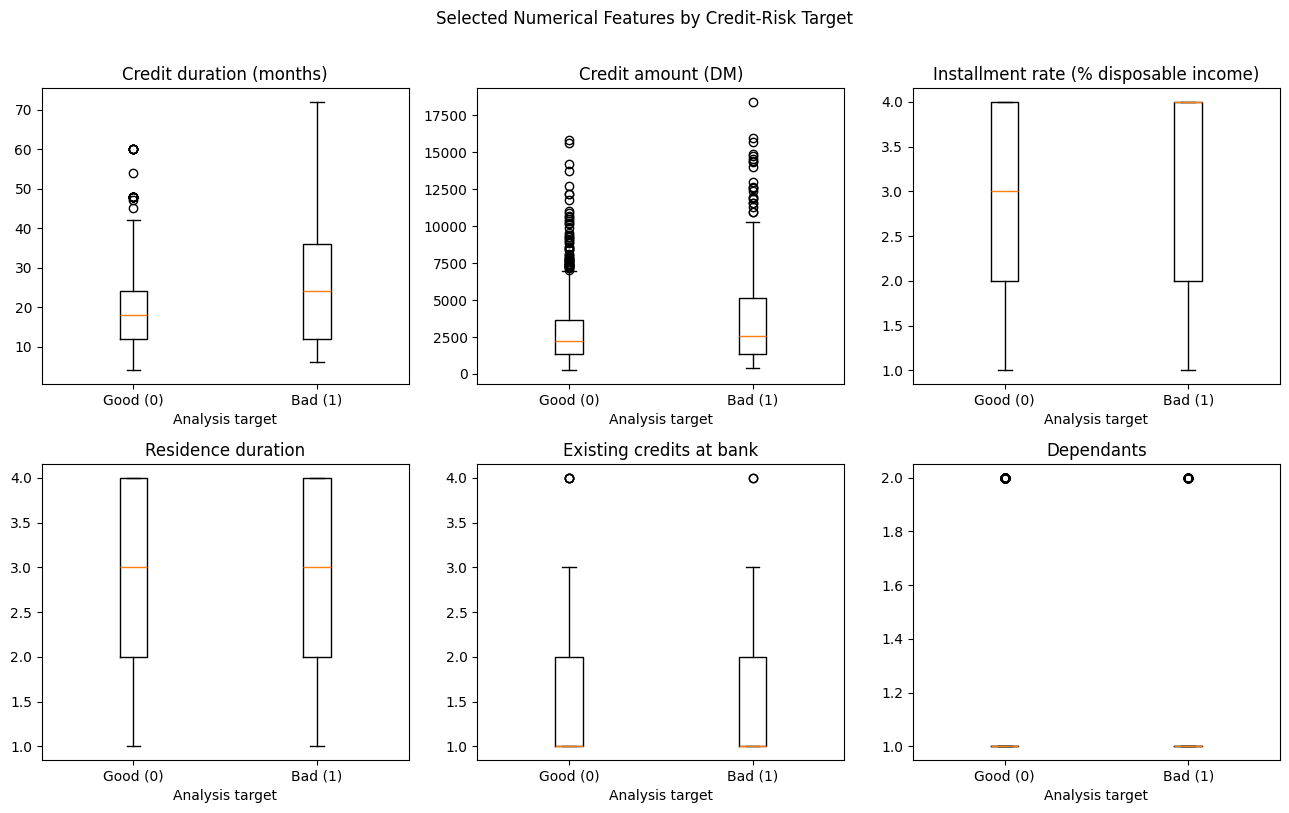

In [7]:
numeric_rows = []
for feature in numeric_selected:
    values = analysis_df[feature]
    q1, median, q3 = values.quantile([0.25, 0.50, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    rho, p_value = spearmanr(values, analysis_df[ANALYSIS_TARGET])
    numeric_rows.append({
        "raw_feature": feature,
        "display_feature": FEATURE_DISPLAY_MAPPING[feature],
        "minimum": values.min(), "maximum": values.max(),
        "median": median, "q1": q1, "q3": q3, "iqr": iqr,
        "skewness": values.skew(), "zero_count": int(values.eq(0).sum()),
        "iqr_extreme_count": int(((values < lower) | (values > upper)).sum()),
        "spearman_with_TARGET": rho, "spearman_p_value": p_value,
        "mean_TARGET_0": analysis_df.loc[analysis_df[ANALYSIS_TARGET].eq(0), feature].mean(),
        "mean_TARGET_1": analysis_df.loc[analysis_df[ANALYSIS_TARGET].eq(1), feature].mean(),
    })
numeric_analysis = pd.DataFrame(numeric_rows)
numeric_analysis.to_csv(ARTIFACTS_DIR / "numeric_feature_analysis.csv", index=False)
display(numeric_analysis)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for axis, feature in zip(axes.ravel(), numeric_selected):
    groups = [analysis_df.loc[analysis_df[ANALYSIS_TARGET].eq(value), feature] for value in (0, 1)]
    axis.boxplot(groups, tick_labels=["Good (0)", "Bad (1)"], showfliers=True)
    axis.set_title(FEATURE_DISPLAY_MAPPING[feature])
    axis.set_xlabel("Analysis target")
plt.suptitle("Selected Numerical Features by Credit-Risk Target", y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "stage02_numeric_features_by_target.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Categorical feature analysis

A rare level is defined descriptively as fewer than 20 observations or under 2% of the dataset. No levels are merged.


In [8]:
RARE_COUNT_THRESHOLD = 20
RARE_PERCENT_THRESHOLD = 2.0
categorical_rows = []
for feature in categorical_selected:
    counts = analysis_df[feature].value_counts(dropna=False)
    for raw_value, count in counts.items():
        subset = analysis_df.loc[analysis_df[feature].eq(raw_value)]
        percentage = count / len(analysis_df) * 100
        categorical_rows.append({
            "raw_feature": feature,
            "display_feature": FEATURE_DISPLAY_MAPPING[feature],
            "raw_value": raw_value,
            "category_label": CATEGORY_VALUE_MAPPING[feature][raw_value],
            "count": int(count),
            "percentage": percentage,
            "higher_risk_count": int(subset[ANALYSIS_TARGET].sum()),
            "higher_risk_rate": subset[ANALYSIS_TARGET].mean(),
            "rare_level": bool(count < RARE_COUNT_THRESHOLD or percentage < RARE_PERCENT_THRESHOLD),
        })
categorical_analysis = pd.DataFrame(categorical_rows)
categorical_analysis.to_csv(ARTIFACTS_DIR / "categorical_feature_analysis.csv", index=False)
rare_levels = categorical_analysis.loc[categorical_analysis["rare_level"]].sort_values(["count", "raw_feature"])
rare_levels.to_csv(ARTIFACTS_DIR / "rare_category_audit.csv", index=False)

display(categorical_analysis)
print(f"Categorical levels: {len(categorical_analysis)}")
print(f"Rare levels flagged: {len(rare_levels)}")
display(rare_levels)


,raw_feature,display_feature,raw_value,category_label,count,percentage,higher_risk_count,higher_risk_rate,rare_level
0,Attribute1,Checking account status,A14,No checking account,394,39.4,46,0.116751,False
1,Attribute1,Checking account status,A11,< 0 DM,274,27.4,135,0.492701,False
2,Attribute1,Checking account status,A12,0 to < 200 DM,269,26.9,105,0.390335,False
3,Attribute1,Checking account status,A13,>= 200 DM or salary assignment >= 1 year,63,6.3,14,0.222222,False
4,Attribute3,Credit history,A32,Existing credits paid duly to date,530,53.0,169,0.318868,False
5,Attribute3,Credit history,A34,Critical account or other existing credits,293,29.3,50,0.170648,False
6,Attribute3,Credit history,A33,Past payment delay,88,8.8,28,0.318182,False
7,Attribute3,Credit history,A31,All credits at this bank paid duly,49,4.9,28,0.571429,False
8,Attribute3,Credit history,A30,No credits taken or all credits paid duly,40,4.0,25,0.625000,False
9,Attribute4,Credit purpose,A43,Radio or television,280,28.0,62,0.221429,False


Categorical levels: 48
Rare levels flagged: 3


,raw_feature,display_feature,raw_value,category_label,count,percentage,higher_risk_count,higher_risk_rate,rare_level
18,Attribute4,Credit purpose,A48,Retraining,9,0.9,1,0.111111,True
16,Attribute4,Credit purpose,A44,Domestic appliances,12,1.2,4,0.333333,True
17,Attribute4,Credit purpose,A410,Other,12,1.2,5,0.416667,True


## 8. Association and redundancy

Spearman correlation is used for integer features. Bias-corrected Cramér’s V is used for categorical pairs; only the strongest pairs are displayed.


Strongest numerical pairs:


,feature_1,feature_2,association_method,association,absolute_association
0,Attribute2,Attribute5,Spearman rho,0.624709,0.624709
5,Attribute5,Attribute8,Spearman rho,-0.313100,0.313100
1,Attribute2,Attribute8,Spearman rho,0.118046,0.118046
14,Attribute16,Attribute18,Spearman rho,0.096978,0.096978
11,Attribute8,Attribute18,Spearman rho,-0.072543,0.072543
12,Attribute11,Attribute16,Spearman rho,0.067193,0.067193
9,Attribute8,Attribute11,Spearman rho,0.047507,0.047507
2,Attribute2,Attribute11,Spearman rho,0.043671,0.043671
4,Attribute2,Attribute18,Spearman rho,-0.043265,0.043265
8,Attribute5,Attribute18,Spearman rho,0.041815,0.041815


Strongest categorical pairs:


,feature_1,feature_2,association_method,association,absolute_association
46,Attribute12,Attribute15,bias-corrected Cramer's V,0.551012,0.551012
54,Attribute17,Attribute19,bias-corrected Cramer's V,0.422363,0.422363
38,Attribute7,Attribute17,bias-corrected Cramer's V,0.305272,0.305272
15,Attribute3,Attribute14,bias-corrected Cramer's V,0.206069,0.206069
26,Attribute4,Attribute19,bias-corrected Cramer's V,0.199263,0.199263
48,Attribute12,Attribute19,bias-corrected Cramer's V,0.190158,0.190158
24,Attribute4,Attribute15,bias-corrected Cramer's V,0.187704,0.187704
47,Attribute12,Attribute17,bias-corrected Cramer's V,0.186280,0.186280
22,Attribute4,Attribute12,bias-corrected Cramer's V,0.182900,0.182900
25,Attribute4,Attribute17,bias-corrected Cramer's V,0.179537,0.179537


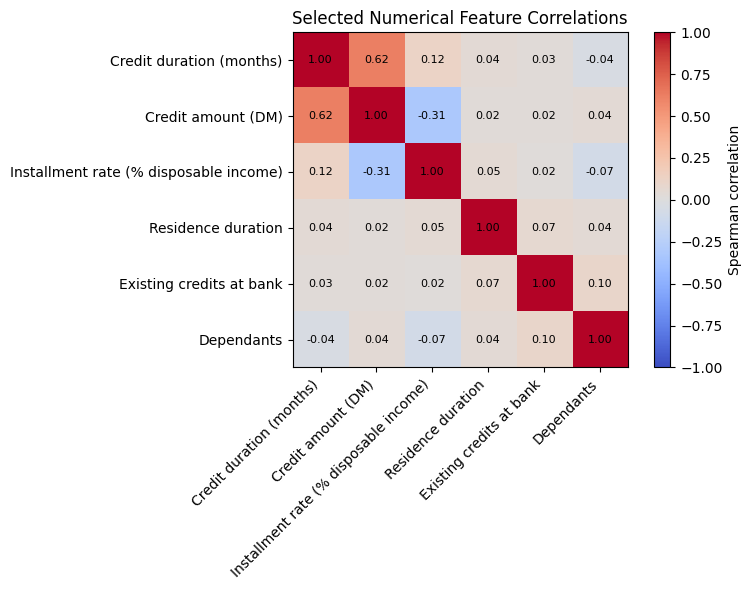

In [9]:
spearman_matrix = analysis_df[numeric_selected].corr(method="spearman")
numeric_pairs = []
for left_index, left in enumerate(numeric_selected):
    for right in numeric_selected[left_index + 1:]:
        numeric_pairs.append({
            "feature_1": left, "feature_2": right,
            "association_method": "Spearman rho",
            "association": float(spearman_matrix.loc[left, right]),
            "absolute_association": abs(float(spearman_matrix.loc[left, right])),
        })
numeric_pairwise = pd.DataFrame(numeric_pairs).sort_values("absolute_association", ascending=False)

def corrected_cramers_v(left, right):
    table = pd.crosstab(left, right)
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    phi2 = chi2 / n
    rows, columns = table.shape
    phi2_corrected = max(0, phi2 - ((columns - 1) * (rows - 1)) / (n - 1))
    rows_corrected = rows - ((rows - 1) ** 2) / (n - 1)
    columns_corrected = columns - ((columns - 1) ** 2) / (n - 1)
    denominator = min(columns_corrected - 1, rows_corrected - 1)
    return np.sqrt(phi2_corrected / denominator) if denominator > 0 else 0.0

categorical_pairs = []
for left_index, left in enumerate(categorical_selected):
    for right in categorical_selected[left_index + 1:]:
        value = corrected_cramers_v(analysis_df[left], analysis_df[right])
        categorical_pairs.append({
            "feature_1": left, "feature_2": right,
            "association_method": "bias-corrected Cramer's V",
            "association": value, "absolute_association": value,
        })
categorical_pairwise = pd.DataFrame(categorical_pairs).sort_values("absolute_association", ascending=False)
association_summary = pd.concat([numeric_pairwise.head(10), categorical_pairwise.head(10)], ignore_index=True)
association_summary.to_csv(ARTIFACTS_DIR / "feature_association_summary.csv", index=False)

print("Strongest numerical pairs:")
display(numeric_pairwise.head(10))
print("Strongest categorical pairs:")
display(categorical_pairwise.head(10))

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(spearman_matrix, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_selected)), [FEATURE_DISPLAY_MAPPING[f] for f in numeric_selected], rotation=45, ha="right")
ax.set_yticks(range(len(numeric_selected)), [FEATURE_DISPLAY_MAPPING[f] for f in numeric_selected])
for row in range(len(numeric_selected)):
    for column in range(len(numeric_selected)):
        ax.text(column, row, f"{spearman_matrix.iloc[row, column]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=ax, label="Spearman correlation")
ax.set_title("Selected Numerical Feature Correlations")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "stage02_numeric_spearman_correlation.png", dpi=180, bbox_inches="tight")
plt.show()


## 9. Exploratory target association

Categorical association uses Cramér’s V against the binary analysis target. These values describe the sample and are not used for automatic feature selection.


In [10]:
categorical_target_rows = []
for feature in categorical_selected:
    value = corrected_cramers_v(analysis_df[feature], analysis_df[ANALYSIS_TARGET])
    rates = analysis_df.groupby(feature)[ANALYSIS_TARGET].agg(["count", "mean"])
    categorical_target_rows.append({
        "raw_feature": feature,
        "display_feature": FEATURE_DISPLAY_MAPPING[feature],
        "cramers_v_with_TARGET": value,
        "minimum_category_bad_rate": rates["mean"].min(),
        "maximum_category_bad_rate": rates["mean"].max(),
        "bad_rate_range": rates["mean"].max() - rates["mean"].min(),
        "smallest_category_count": int(rates["count"].min()),
    })
categorical_target_association = pd.DataFrame(categorical_target_rows).sort_values("cramers_v_with_TARGET", ascending=False)
categorical_target_association.to_csv(ARTIFACTS_DIR / "categorical_target_association.csv", index=False)
display(categorical_target_association)


,raw_feature,display_feature,cramers_v_with_TARGET,minimum_category_bad_rate,maximum_category_bad_rate,bad_rate_range,smallest_category_count
0,Attribute1,Checking account status,0.347619,0.116751,0.492701,0.375949,63
1,Attribute3,Credit history,0.240302,0.170648,0.625000,0.454352,40
3,Attribute6,Savings account status,0.179240,0.125000,0.359867,0.234867,48
2,Attribute4,Credit purpose,0.156115,0.111111,0.440000,0.328889,9
6,Attribute12,Property,0.144005,0.212766,0.435065,0.222299,154
8,Attribute15,Housing,0.127334,0.260870,0.407407,0.146538,108
4,Attribute7,Employment duration,0.119911,0.224138,0.406977,0.182839,62
7,Attribute14,Other installment plans,0.104154,0.275184,0.410072,0.134888,47
5,Attribute10,Other debtors or guarantors,0.068176,0.192308,0.439024,0.246717,41
10,Attribute19,Registered telephone,0.018141,0.279703,0.313758,0.034055,404


## 10. Small-sample representation risk

The expected dimension assumes all observed levels are retained by one-hot encoding. This is an estimate only; no encoder is fitted.


In [11]:
category_levels = {feature: int(analysis_df[feature].nunique()) for feature in categorical_selected}
expected_one_hot_columns = sum(category_levels.values())
expected_transformed_features = len(numeric_selected) + expected_one_hot_columns
expected_training_rows = int(len(analysis_df) * 0.80)
small_sample_summary = pd.DataFrame([
    {"measure": "Expected training observations", "value": expected_training_rows},
    {"measure": "Selected raw features", "value": len(selected_features)},
    {"measure": "Selected numeric features", "value": len(numeric_selected)},
    {"measure": "Selected categorical features", "value": len(categorical_selected)},
    {"measure": "Observed categorical levels", "value": expected_one_hot_columns},
    {"measure": "Estimated transformed features", "value": expected_transformed_features},
    {"measure": "Training observations per transformed feature", "value": expected_training_rows / expected_transformed_features},
    {"measure": "Rare levels flagged", "value": len(rare_levels)},
])
display(small_sample_summary)

small_sample_risk = {
    "expected_training_rows": expected_training_rows,
    "selected_raw_features": len(selected_features),
    "observed_one_hot_levels": expected_one_hot_columns,
    "estimated_transformed_feature_count": expected_transformed_features,
    "rare_level_definition": "count < 20 or percentage < 2",
    "rare_levels_flagged": int(len(rare_levels)),
    "risk": "Sparse levels and about 800 training rows create overfitting risk; retain a compact pipeline and validate only within training data.",
}
with (ARTIFACTS_DIR / "small_sample_risk.json").open("w", encoding="utf-8") as file:
    json.dump(small_sample_risk, file, indent=2)


,measure,value
0,Expected training observations,800.000000
1,Selected raw features,17.000000
2,Selected numeric features,6.000000
3,Selected categorical features,11.000000
4,Observed categorical levels,48.000000
5,Estimated transformed features,54.000000
6,Training observations per transformed feature,14.814815
7,Rare levels flagged,3.000000


## 11. Stage 03 recommendation

Numeric features have no native missing values. XGBoost does not require scaling, and observed extremes should initially be retained with checks for data-entry validity.

Categorical features should use one-hot encoding with unknown-category handling. Rare levels should be reviewed within training data only before deciding whether to group them. The target mapping will be `1 → 0` and `2 → 1`.


In [12]:
validation_plan = {
    "holdout": {"train_fraction": 0.80, "test_fraction": 0.20, "random_state": RANDOM_STATE, "stratify": ANALYSIS_TARGET, "execute_in_stage": "03_data_preprocessing"},
    "model_development": {"method": "StratifiedKFold", "n_splits": 5, "scope": "training data only"},
    "target_mapping": {"1": 0, "2": 1},
    "uci_cost_matrix": {"actual_1_predicted_1": 0, "actual_1_predicted_2": 1, "actual_2_predicted_1": 5, "actual_2_predicted_2": 0},
    "cost_matrix_use": "Additional later model-evaluation measure; not the target definition and not used for Stage 02 training.",
    "numeric_recommendation": "Retain numeric values; no scaling required for XGBoost; keep extreme values unless verified erroneous.",
    "categorical_recommendation": "One-hot encode with handle_unknown='ignore'; decide any rare-level grouping from training data only.",
    "estimated_transformed_feature_count": expected_transformed_features,
    "split_created": False,
}
with (ARTIFACTS_DIR / "stage03_recommendation.json").open("w", encoding="utf-8") as file:
    json.dump(validation_plan, file, indent=2)
display(pd.Series(validation_plan, name="recommendation").to_frame())


,recommendation
holdout,"{'train_fraction': 0.8, 'test_fraction': 0.2, ..."
model_development,"{'method': 'StratifiedKFold', 'n_splits': 5, '..."
target_mapping,"{'1': 0, '2': 1}"
uci_cost_matrix,"{'actual_1_predicted_1': 0, 'actual_1_predicte..."
cost_matrix_use,Additional later model-evaluation measure; not...
numeric_recommendation,Retain numeric values; no scaling required for...
categorical_recommendation,One-hot encode with handle_unknown='ignore'; d...
estimated_transformed_feature_count,54
split_created,False


## 12. Preliminary XAI actionability review

These labels are provisional. They indicate whether a feature could plausibly be varied in a future counterfactual study, not whether changing it is easy or appropriate.


In [13]:
ACTIONABILITY = {
    "Attribute1": ("partially_actionable", "Account status may change over time but is not an immediate loan-design variable."),
    "Attribute2": ("likely_actionable", "Requested credit duration can be adjusted in an application scenario."),
    "Attribute3": ("non_actionable", "Historical credit record cannot be changed for the current decision."),
    "Attribute4": ("partially_actionable", "Credit purpose is applicant-led but constrained by the real need."),
    "Attribute5": ("likely_actionable", "Requested credit amount can be adjusted."),
    "Attribute6": ("partially_actionable", "Savings position may change over time, not immediately."),
    "Attribute7": ("non_actionable", "Employment duration is historical."),
    "Attribute8": ("likely_actionable", "Installment rate is linked to loan design and affordability."),
    "Attribute10": ("partially_actionable", "A guarantor or co-applicant may be possible but depends on another person."),
    "Attribute11": ("non_actionable", "Residence duration is historical."),
    "Attribute12": ("non_actionable", "Property status is not realistically mutable for an immediate decision."),
    "Attribute14": ("partially_actionable", "Other installment commitments may change over time."),
    "Attribute15": ("non_actionable", "Housing tenure is not realistically mutable for an immediate decision."),
    "Attribute16": ("partially_actionable", "Existing credit commitments may reduce over time."),
    "Attribute17": ("non_actionable", "Job status is not an appropriate immediate counterfactual lever."),
    "Attribute18": ("non_actionable", "Number of dependants should not be treated as an actionable lever."),
    "Attribute19": ("partially_actionable", "Telephone registration can change but has weak substantive actionability."),
}
actionability_audit = pd.DataFrame([
    {"feature": feature, "display_feature": FEATURE_DISPLAY_MAPPING[feature], "actionability_candidate": ACTIONABILITY[feature][0], "reason": ACTIONABILITY[feature][1]}
    for feature in selected_features
])
actionability_audit.to_csv(ARTIFACTS_DIR / "xai_actionability_audit.csv", index=False)
display(actionability_audit)


,feature,display_feature,actionability_candidate,reason
0,Attribute1,Checking account status,partially_actionable,Account status may change over time but is not...
1,Attribute2,Credit duration (months),likely_actionable,Requested credit duration can be adjusted in a...
2,Attribute3,Credit history,non_actionable,Historical credit record cannot be changed for...
3,Attribute4,Credit purpose,partially_actionable,Credit purpose is applicant-led but constraine...
4,Attribute5,Credit amount (DM),likely_actionable,Requested credit amount can be adjusted.
5,Attribute6,Savings account status,partially_actionable,"Savings position may change over time, not imm..."
6,Attribute7,Employment duration,non_actionable,Employment duration is historical.
7,Attribute8,Installment rate (% disposable income),likely_actionable,Installment rate is linked to loan design and ...
8,Attribute10,Other debtors or guarantors,partially_actionable,A guarantor or co-applicant may be possible bu...
9,Attribute11,Residence duration,non_actionable,Residence duration is historical.


## 13. Requirements integrity

Stage 01 added the official UCI client. No dependency change is needed for this stage.


In [14]:
requirements = [line.strip() for line in REQUIREMENTS_PATH.read_text(encoding="utf-8").splitlines() if line.strip()]
requirement_names = [line.split("==")[0].split("[")[0].lower() for line in requirements]
requirements_check = {
    "ucimlrepo_0_0_7_present_once": requirements.count("ucimlrepo==0.0.7") == 1,
    "duplicate_requirement_names": sorted({name for name in requirement_names if requirement_names.count(name) > 1}),
    "stage02_dependency_added": False,
    "stage01_change_review": "Compared with the pre-normalisation Stage 01 dependency inventory: ucimlrepo==0.0.7 was the only semantic addition; existing package names and versions were retained.",
}
assert requirements_check["ucimlrepo_0_0_7_present_once"]
assert not requirements_check["duplicate_requirement_names"]
display(pd.Series(requirements_check, name="result").to_frame())


,result
ucimlrepo_0_0_7_present_once,True
duplicate_requirement_names,[]
stage02_dependency_added,False
stage01_change_review,Compared with the pre-normalisation Stage 01 d...


## 14. Quality checks and stop condition


In [15]:
assert len(raw_df) == 1000
assert len(raw_features) == 20
assert set(analysis_df[ANALYSIS_TARGET].unique()) == {0, 1}
assert int(analysis_df[ANALYSIS_TARGET].sum()) == 300
assert int(analysis_df[ANALYSIS_TARGET].eq(0).sum()) == 700
assert all(feature not in selected_features for feature in EXCLUDED_FEATURES)
assert len(selected_features) == 17
assert len(numeric_selected) == 6
assert len(categorical_selected) == 11
assert raw_sha256 == EXPECTED_RAW_SHA256
assert validation_plan["split_created"] is False
assert not any(path.name.startswith(("train_indices", "test_indices", "preprocessor", "model")) for path in ARTIFACTS_DIR.iterdir())

print("Raw rows: 1000")
print("Raw predictors: 20")
print("TARGET values: {0, 1}")
print("TARGET positives: 300")
print("TARGET negatives: 700")
print(f"Primary selected features: {len(selected_features)}")
print(f"Estimated transformed features: {expected_transformed_features}")
print("Preprocessing fitted: False")
print("Train/test split created: False")
print("Model fitted: False")
print("XAI method executed: False")
print("Stage 02 checks passed.")


Raw rows: 1000
Raw predictors: 20
TARGET values: {0, 1}
TARGET positives: 300
TARGET negatives: 700
Primary selected features: 17
Estimated transformed features: 54
Preprocessing fitted: False
Train/test split created: False
Model fitted: False
XAI method executed: False
Stage 02 checks passed.


## 15. Points to approve before Stage 03

- Confirm the 17-feature primary set and the provisional actionability labels.
- Confirm whether rare levels should remain separate or be grouped using training-only evidence.
- Confirm one-hot encoding with unknown-category handling and no numeric scaling for XGBoost.
- Confirm the frozen 80/20 stratified split and 5-fold training-only validation plan.
- Confirm use of the UCI cost matrix as an additional evaluation measure.

Stage 03 has not been created.
